In [1]:
import os
os.chdir('../../../../..')

In [2]:
import polars as pl
import numpy as np

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from kmedoids import KMedoids
from hdbscan import HDBSCAN

from src.helper_functions import create_chemiscope_viewer, average_numeric_by_cluster, plot_distance_matrix_projection
from src.datasets import QM9Dataset
from src.non_euclidean import Riemann, Grassmann, Wasserstein, PersistentHomology

INFO: Enabling RDKit 2025.09.4 jupyter extensions


In [3]:
qm9 = QM9Dataset(limit=1500, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"])
df = qm9.load()
molecules = qm9.get_molecules()

2026-04-28 11:57:26.041 | INFO     | src.datasets:load:864 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-28 11:57:26.499 | INFO     | src.datasets:_sample_qm9_df:1064 - QM9 sampling complete: strategy=stratified, requested_limit=1500, returned_rows=1500.
2026-04-28 11:57:26.500 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=1500).
2026-04-28 11:57:26.500 | INFO     | src.datasets:_add_requested_descriptors:229 - No new descriptor columns added (already present or none requested).
2026-04-28 11:57:26.692 | SUCCESS  | src.datasets:get_molecules:1676 - Saved 1500 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 1500).


In [4]:
persistent = PersistentHomology()
distance_matrix = persistent.distance_matrix(frames=molecules)

2026-04-28 11:57:26.698 | INFO     | src.non_euclidean:_load_cached_distance_matrix:304 - Loading cached persistent_homology distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/QM9/non_euclidean_cache/persistent_homology_n1500_unknown_bottleneck_maxdim2_dims0-1-2.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_57067/1358273975.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='average')


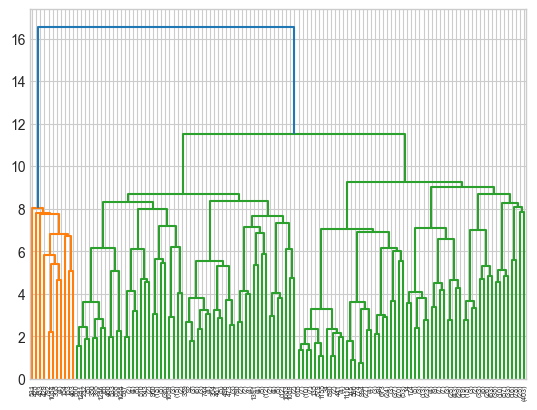

In [31]:
Z = linkage(distance_matrix, method='average')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=7, 
)

In [32]:
model_hier_ph = AgglomerativeClustering(metric='precomputed', n_clusters=12, linkage='average')
labels_hier_ph = model_hier_ph.fit_predict(distance_matrix)
print(np.unique(labels_hier_ph, return_counts=True))
df = df.with_columns(labels_hier_ph=labels_hier_ph)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]), array([404, 130,  43, 208, 158, 379,  18,  44,  13,  23,   1,  79]))


In [33]:
create_chemiscope_viewer(df, distance_matrix, labels_hier_ph, 'UMAP')

2026-04-28 12:27:57.116 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running UMAP dimensionality reduction...
2026-04-28 12:27:57.117 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-04-28 12:28:04.737 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-28 12:28:04.739 | INFO     | src.helper_funct

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


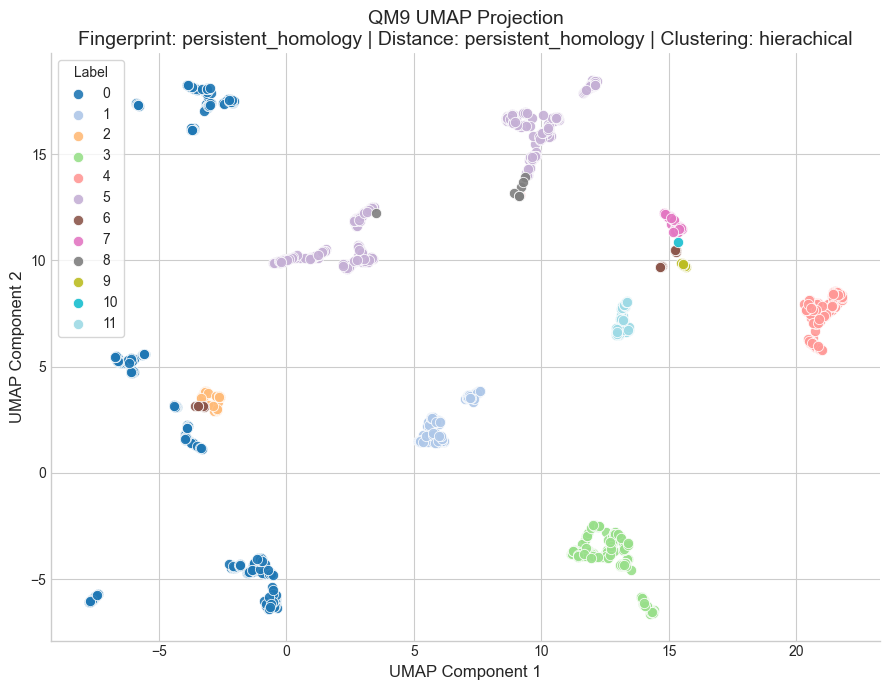

2026-04-28 12:28:18.980 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved UMAP projection plot to figures/qm9/clustering/persistent_homology/persistent_homology/umap_hierachical_projection.png


In [34]:
_ = plot_distance_matrix_projection(
    dist_matrix=distance_matrix,
    fingerprint="persistent_homology",
    distance_metric="persistent_homology",
    projection_method="UMAP",
    dataset_name="qm9",
    labels=labels_hier_ph,
    clustering_method="hierachical"
)

In [25]:
average_numeric_by_cluster(df, "labels_hier_ph")

shape: (12, 72)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬───────────┬───────────┬───────────┬──────────┬────────┬────────┬────────┬────────────────┬────────────────┬──────────────┬─────────────┬────────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬

labels_hier_ph,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier_riemann,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,50,2.181922,0.0,125.52,0.56,19.6,0.961875,12.777041,8.98,2.38,0.04,0.0,1.54,20.94,2.112294,1.48,0.004444,0.084206,0.911349,0.6,1.44,7.56,0.04,0.66,6.74,6.22,45.7,1.267624,0.02,0.42,0.0,0.02,0.0,0.0,0.0,0.08,0.84,0.0,1.705482,80.0058,-6.350539,1.47132,7.82175,1095.390376,4.954498,-10954.948906,-10954.72875,-10954.703145,-10955.829043,32.3487,-86.554599,-87.136033,-87.644965,-80.436239,2.652617,1.602533,1.306143,10.8,96.0,4.0,0.0,45.7,46,"""C1CCOCC1""",4.0,25,"""C1CCC2CC2C1""",16.0,1,null,0.0
1,295,2.103061,0.0,122.99661,0.335593,29.935593,0.904267,12.832657,8.772881,1.4,0.030508,0.020339,1.935593,20.027119,2.027341,3.315254,0.084373,0.104861,0.810765,0.844068,1.654237,6.708475,0.562712,0.681356,5.59322,6.650847,42.464407,1.254344,0.0,0.430508,0.00339,0.067797,0.088136,0.00339,0.020339,0.101695,0.444068,0.0,2.412317,79.009797,-6.631046,0.734495,7.365495,1331.118025,4.598417,-10868.868088,-10868.614064,-10868.5884,-10869.806717,34.341783,-81.866408,-82.376364,-82.860108,-76.107201,3.7635,1.223773,1.02109,1.0,72.542373,3.050847,24.40678,42.464407,117,"""Acyclic""",24.40678,52,"""Acyclic""",24.40678,1,null,0.0
2,202,1.85615,0.0,119.782178,-0.20297,55.490099,0.737662,12.937269,8.594059,1.509901,0.584158,0.074257,3.623762,14.321782,2.067929,1.480198,0.07632,0.537082,0.386598,1.188119,3.00495,5.386139,0.440594,2.50495,2.024752,6.029703,26.717822,1.271144,0.0,0.257426,0.153465,0.277228,0.084158,0.0,0.064356,0.123762,0.450495,0.0,3.191033,66.653416,-6.465048,-0.637716,5.827399,1036.397579,2.845139,-11650.38413,-11650.181655,-11650.155982,-11651.261127,27.393144,-62.317336,-62.656324,-62.991677,-58.167011,4.048903,1.584043,1.192684,7.717822,45.544554,54.455446,0.0,26.717822,131,"""c1cocn1""",5.445545,38,"""C1CCCC1""",29.70297,1,null,0.0
3,162,1.983285,0.0,122.271605,-0.314815,45.469136,0.806653,12.878433,8.771605,1.617284,0.253086,0.030864,3.061728,16.432099,2.066712,1.765432,0.093416,0.31408,0.592504,1.111111,2.487654,6.018519,0.58642,1.716049,3.407407,6.253086,32.62963,1.266619,0.006173,0.283951,0.030864,0.197531,0.191358,0.0,0.049383,0.17284,0.54321,0.0,3.096974,71.416235,-6.55314,-0.297545,6.255528,1137.936319,3.419497,-11490.133268,-11489.913029,-11489.88743,-11491.033703,29.773037,-69.23722,-69.633681,-70.019184,-64.533054,3.580555,1.418255,1.129436,3.0,67.283951,24.691358,8.024691,32.62963,110,"""Acyclic""",8.024691,52,"""C1CCCC1""",15.432099,1,null,0.0
4,208,2.098522,0.0,124.360577,0.086538,31.778846,0.91702,12.806871,8.899038,1.875,0.081731,0.0,2.144231,19.192308,2.076143,2.350962,0.053407,0.160836,0.785756,0.865385,1.850962,6.841346,0.394231,1.081731,5.278846,6.394231,40.288462,1.262953,0.004808,0.432692,0.0,0.091346,0.105769,0.0,0.024038,0.144231,0.658654,0.0,2.530666,77.131154,-6.390058,0.583318,6.973271,1201.309712,4.345846,-11191.900109,-11191.664851,-11191.639123,-11192.813599,32.596567

kmedoids

In [29]:
km = KMedoids(n_clusters=12, metric='precomputed')
labels_km = km.fit_predict(distance_matrix)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


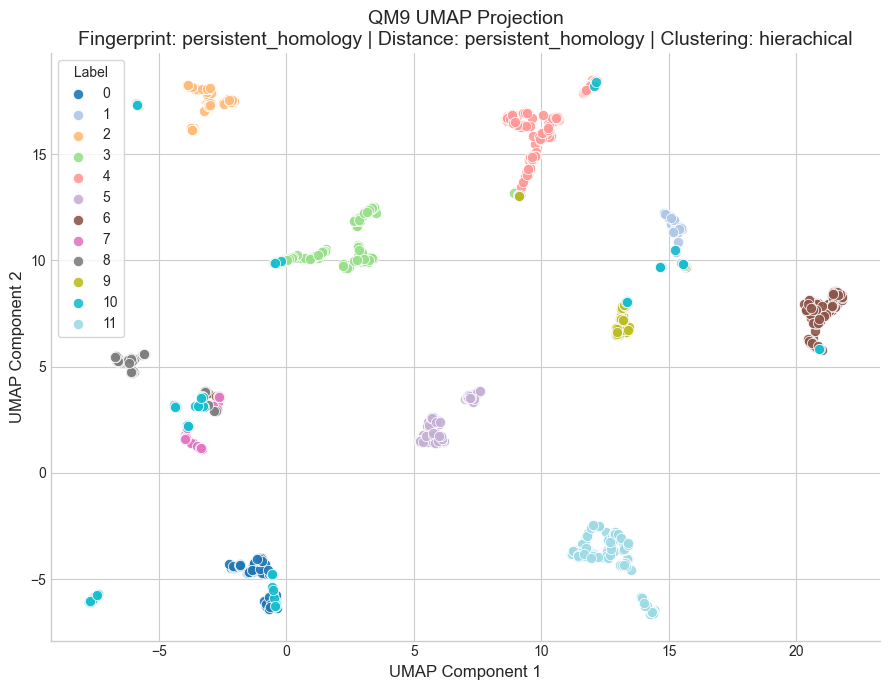

2026-04-28 12:26:37.876 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved UMAP projection plot to figures/qm9/clustering/persistent_homology/persistent_homology/umap_hierachical_projection.png


In [30]:
_ = plot_distance_matrix_projection(
    dist_matrix=distance_matrix,
    fingerprint="persistent_homology",
    distance_metric="persistent_homology",
    projection_method="UMAP",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="hierachical"
)